# Activity 01: Pima Indian Diabetes (Classification)

**Objective:** Apply preprocessing techniques to prepare the data for a Machine Learning classification model.

**Dataset:** Pima Indians Diabetes Database (UCI / Kaggle), 768 records of female patients, with 8 predictor
attributes and 1 target attribute (`Outcome`).


## 1. Load and explore the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

# Loading the dataset with read_csv()
df = pd.read_csv('../../datasets/diabetes.csv')

print('Dataset shape (rows, columns):', df.shape)
df.head()


Dataset shape (rows, columns): (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
# General information: columns, data types and non-null counts
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [3]:
# Descriptive statistics for all numeric columns
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


## 2. Remove irrelevant attributes

The original Kaggle dataset is already lean: it has 8 predictor variables (all physiologically relevant for
diagnosing diabetes) plus the target variable `Outcome`. There are no identifier columns (e.g. `ID`, `PatientID`)
and no completely empty or constant columns.

Even so, it is good practice to verify this programmatically instead of just assuming it.


In [4]:
# Check for completely empty columns, constant columns (zero variance), or ID-like columns
constant_columns = [c for c in df.columns if df[c].nunique() == 1]
empty_columns = [c for c in df.columns if df[c].isnull().all()]

print('Constant columns (no variance):', constant_columns)
print('Completely empty columns:', empty_columns)
print('Number of unique values per column:')
print(df.nunique())


Constant columns (no variance): []
Completely empty columns: []
Number of unique values per column:
Pregnancies                  17
Glucose                     136
BloodPressure                47
SkinThickness                51
Insulin                     186
BMI                         248
DiabetesPedigreeFunction    517
Age                          52
Outcome                       2
dtype: int64


**Conclusion:** no constant, empty, or identifier columns were found. Therefore, **no attribute will be
removed** — all 8 predictor variables (`Pregnancies`, `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`,
`BMI`, `DiabetesPedigreeFunction`, `Age`) and the target (`Outcome`) will be kept.


## 3. Handling missing data

The `isnull()` method finds no explicit `NaN` values in this dataset. However, this is a classic issue with the
Pima Indians Diabetes dataset: physiologically impossible values were recorded as **0** instead of `NaN` in the
columns `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` (no living person has zero blood
glucose, blood pressure, BMI, etc.). These zeros are, in practice, **disguised missing values**.


In [5]:
# Direct null check (finds nothing, as expected)
print('Null values per column (isnull):')
print(df.isnull().sum())


Null values per column (isnull):
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [6]:
# Columns where a value of 0 is physiologically impossible, and therefore indicates a missing value
invalid_zero_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print('Number of zeros (disguised missing values) per column:')
for c in invalid_zero_columns:
    print(f'{c}: {(df[c] == 0).sum()} zeros out of {len(df)} records ({(df[c] == 0).mean()*100:.1f}%)')


Number of zeros (disguised missing values) per column:
Glucose: 5 zeros out of 768 records (0.7%)
BloodPressure: 35 zeros out of 768 records (4.6%)
SkinThickness: 227 zeros out of 768 records (29.6%)
Insulin: 374 zeros out of 768 records (48.7%)
BMI: 11 zeros out of 768 records (1.4%)


In [7]:
# Replace invalid zeros with NaN so they are treated as actual missing values
df_clean = df.copy()
df_clean[invalid_zero_columns] = df_clean[invalid_zero_columns].replace(0, np.nan)

print('Missing values after converting zeros to NaN:')
print(df_clean.isnull().sum())


Missing values after converting zeros to NaN:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [8]:
# Imputation: fill missing values with the MEDIAN of each column, computed per class (Outcome),
# to better preserve the distribution of diabetic vs. non-diabetic patients.
for c in invalid_zero_columns:
    df_clean[c] = df_clean.groupby('Outcome')[c].transform(lambda x: x.fillna(x.median()))

print('Missing values after median imputation (per class):')
print(df_clean.isnull().sum())
df_clean[invalid_zero_columns].describe().T


Missing values after median imputation (per class):
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
Glucose,768.0,121.677083,30.464161,44.0,99.75,117.00,140.25,199.0
BloodPressure,768.0,72.389323,12.106039,24.0,64.00,72.00,80.00,122.0
SkinThickness,768.0,29.089844,8.890820,7.0,25.00,28.00,32.00,99.0
Insulin,768.0,141.753906,89.100847,14.0,102.50,102.50,169.50,846.0
BMI,768.0,32.434635,6.880498,18.2,27.50,32.05,36.60,67.1


## 4. Handling inconsistent data

In addition to the zeros already treated as missing values, let's check for other common inconsistencies:
- Duplicate records;
- Values outside plausible ranges (e.g. negative age, negative number of pregnancies);
- Data types incoherent with the meaning of the variable.


In [9]:
# Duplicates
duplicates = df_clean.duplicated().sum()
print('Number of duplicate rows:', duplicates)

# Negative values (should not exist in any of these columns)
non_negative_columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                         'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
for c in non_negative_columns:
    n_neg = (df_clean[c] < 0).sum()
    if n_neg > 0:
        print(f'{c}: {n_neg} negative values found')

print('No negative values found in the checked columns.' if
      all((df_clean[c] < 0).sum() == 0 for c in non_negative_columns) else '')

# Plausible range check for Age and Outcome
print('Age range:', df_clean['Age'].min(), '-', df_clean['Age'].max())
print('Unique Outcome values:', sorted(df_clean['Outcome'].unique()))


Number of duplicate rows: 0
No negative values found in the checked columns.
Age range: 21 - 81
Unique Outcome values: [np.int64(0), np.int64(1)]


**Conclusion:** there are no duplicate rows, negative values, implausible ages, or unexpected classes
(`Outcome` only takes values 0 or 1). The only inconsistencies in the dataset were the physiologically invalid
zeros, already corrected in the previous step.


## 5. Outlier treatment

Outliers are identified using the **IQR (interquartile range)** method and visualized with boxplots before and
after treatment. Instead of removing records (which would shrink the already-small 768-patient dataset), we use
**capping/winsorizing**: values below the lower bound are set to the lower bound, and values above the upper
bound are set to the upper bound.


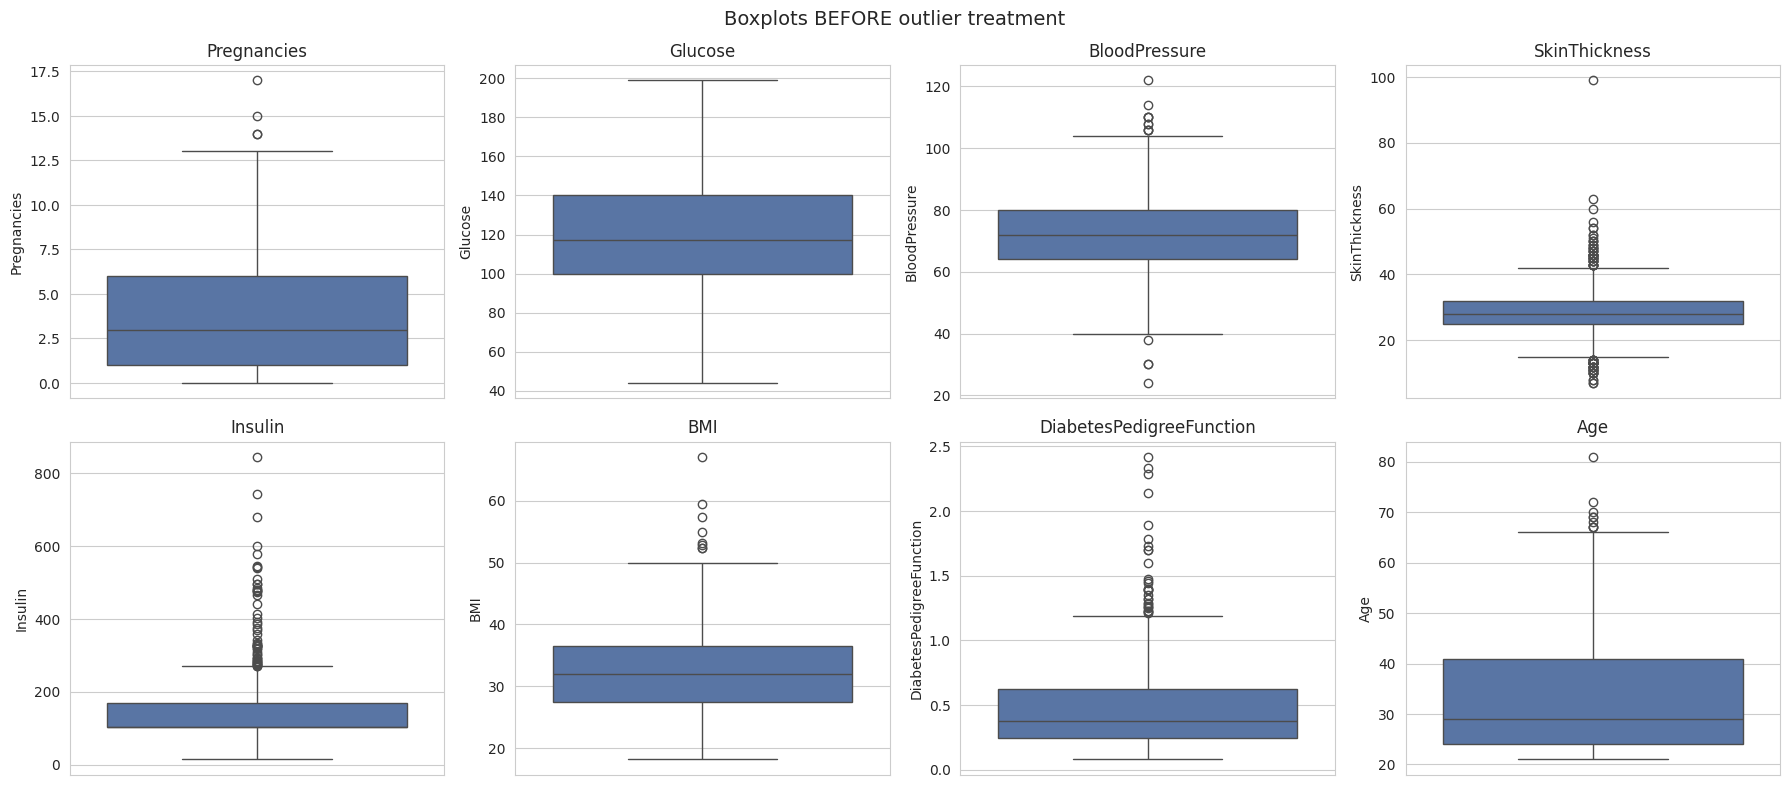

In [10]:
# Boxplots BEFORE outlier treatment
numeric_columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), numeric_columns):
    sns.boxplot(y=df_clean[col], ax=ax, color='#4C72B0')
    ax.set_title(col)
plt.suptitle('Boxplots BEFORE outlier treatment', fontsize=14)
plt.tight_layout()
plt.show()


In [11]:
def iqr_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return lower_bound, upper_bound

print('Number of outliers per column (IQR rule):')
outlier_counts = {}
for col in numeric_columns:
    lb, ub = iqr_bounds(df_clean[col])
    n_out = ((df_clean[col] < lb) | (df_clean[col] > ub)).sum()
    outlier_counts[col] = n_out
    print(f'{col}: {n_out} outliers (bounds: [{lb:.2f}, {ub:.2f}])')


Number of outliers per column (IQR rule):
Pregnancies: 4 outliers (bounds: [-6.50, 13.50])
Glucose: 0 outliers (bounds: [39.00, 201.00])
BloodPressure: 14 outliers (bounds: [40.00, 104.00])
SkinThickness: 87 outliers (bounds: [14.50, 42.50])
Insulin: 51 outliers (bounds: [2.00, 270.00])
BMI: 8 outliers (bounds: [13.85, 50.25])
DiabetesPedigreeFunction: 29 outliers (bounds: [-0.33, 1.20])
Age: 9 outliers (bounds: [-1.50, 66.50])


In [12]:
# Treatment via capping (winsorization): out-of-bound values are set to the nearest bound
df_no_outliers = df_clean.copy()
for col in numeric_columns:
    lb, ub = iqr_bounds(df_no_outliers[col])
    df_no_outliers[col] = df_no_outliers[col].clip(lower=lb, upper=ub)

print('Number of outliers after capping:')
for col in numeric_columns:
    lb, ub = iqr_bounds(df_no_outliers[col])
    n_out = ((df_no_outliers[col] < lb) | (df_no_outliers[col] > ub)).sum()
    print(f'{col}: {n_out} remaining outliers')


Number of outliers after capping:
Pregnancies: 0 remaining outliers
Glucose: 0 remaining outliers
BloodPressure: 0 remaining outliers
SkinThickness: 0 remaining outliers
Insulin: 0 remaining outliers
BMI: 0 remaining outliers
DiabetesPedigreeFunction: 0 remaining outliers
Age: 0 remaining outliers


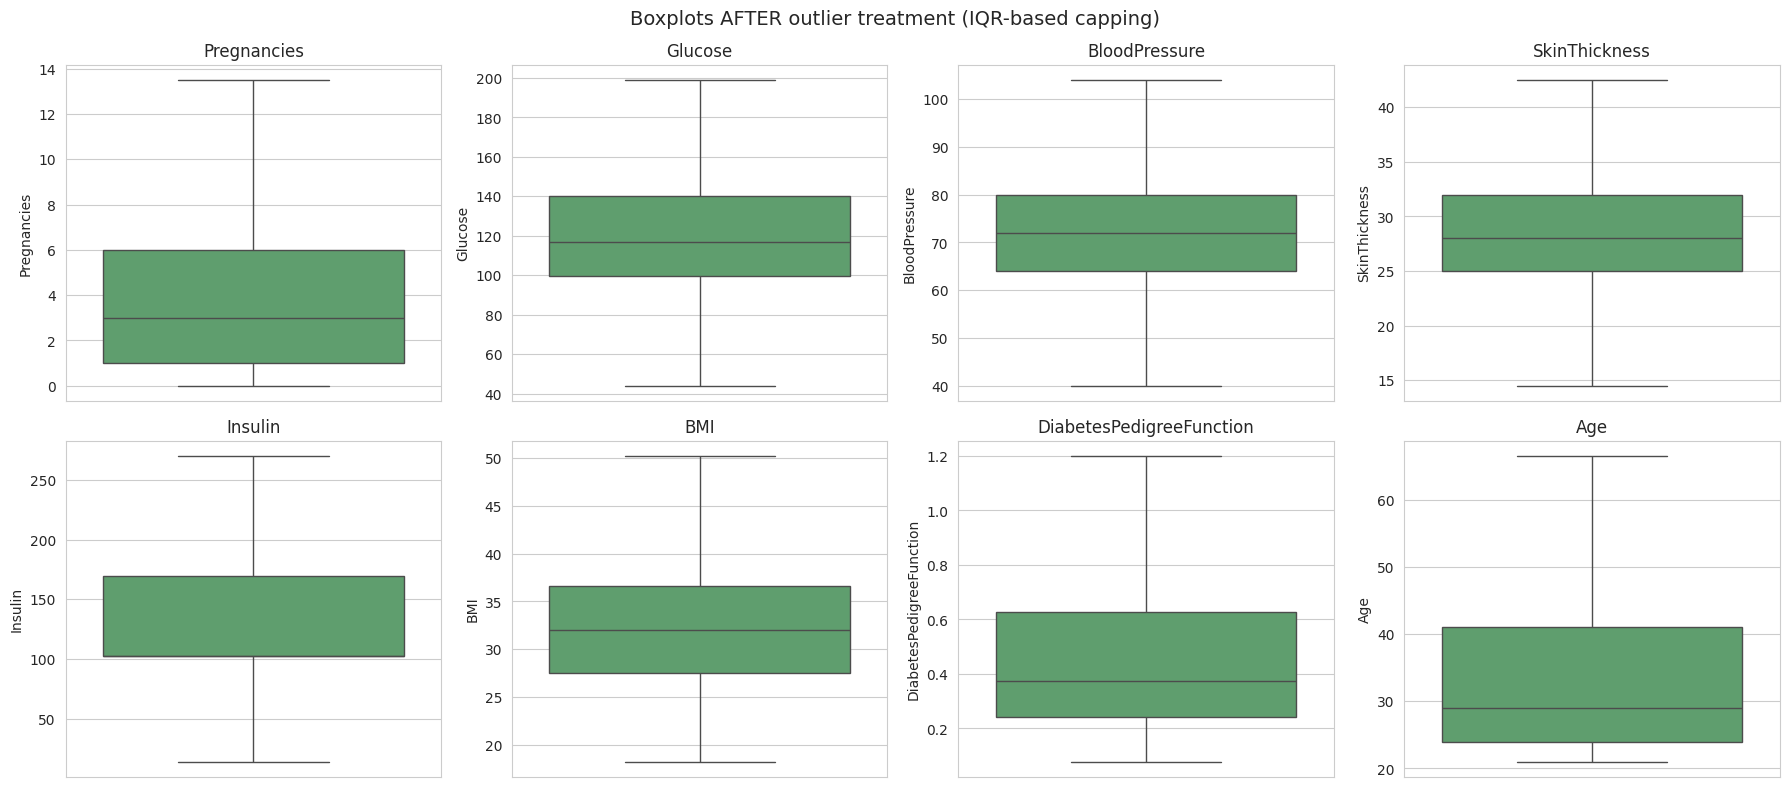

In [13]:
# Boxplots AFTER outlier treatment
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), numeric_columns):
    sns.boxplot(y=df_no_outliers[col], ax=ax, color='#55A868')
    ax.set_title(col)
plt.suptitle('Boxplots AFTER outlier treatment (IQR-based capping)', fontsize=14)
plt.tight_layout()
plt.show()


## 6. Data standardization: MinMaxScaler vs. StandardScaler

Finally, we compare two scaling techniques:

- **MinMaxScaler:** rescales each variable to the [0, 1] range.
- **StandardScaler:** transforms each variable to have mean 0 and standard deviation 1 (z-score standardization).

The target variable (`Outcome`) is not scaled, since it is categorical (0/1).


In [14]:
X = df_no_outliers[numeric_columns]
y = df_no_outliers['Outcome']

minmax_scaler = MinMaxScaler()
X_minmax = pd.DataFrame(minmax_scaler.fit_transform(X), columns=numeric_columns)

standard_scaler = StandardScaler()
X_standard = pd.DataFrame(standard_scaler.fit_transform(X), columns=numeric_columns)

print('Statistics BEFORE scaling:')
display(X.describe().T[['min', 'max', 'mean', 'std']])

print('\nStatistics AFTER MinMaxScaler (expected: min=0, max=1):')
display(X_minmax.describe().T[['min', 'max', 'mean', 'std']])

print('\nStatistics AFTER StandardScaler (expected: mean≈0, std≈1):')
display(X_standard.describe().T[['min', 'max', 'mean', 'std']])


Statistics BEFORE scaling:


,min,max,mean,std
Pregnancies,0.000,13.50,3.837240,3.344157
Glucose,44.000,199.00,121.677083,30.464161
BloodPressure,40.000,104.00,72.360677,11.706821
SkinThickness,14.500,42.50,28.848307,7.559161
Insulin,14.000,270.00,133.085938,58.124185
BMI,18.200,50.25,32.372786,6.672767
DiabetesPedigreeFunction,0.078,1.20,0.458914,0.285596
Age,21.000,66.50,33.199870,11.628404



Statistics AFTER MinMaxScaler (expected: min=0, max=1):


,min,max,mean,std
Pregnancies,0.0,1.0,0.284240,0.247715
Glucose,0.0,1.0,0.501142,0.196543
BloodPressure,0.0,1.0,0.505636,0.182919
SkinThickness,0.0,1.0,0.512440,0.269970
Insulin,0.0,1.0,0.465179,0.227048
BMI,0.0,1.0,0.442209,0.208199
DiabetesPedigreeFunction,0.0,1.0,0.339496,0.254542
Age,0.0,1.0,0.268129,0.255569



Statistics AFTER StandardScaler (expected: mean≈0, std≈1):


,min,max,mean,std
Pregnancies,-1.148194,2.891329,-6.938894e-17,1.000652
Glucose,-2.551447,2.539814,1.480297e-16,1.000652
BloodPressure,-2.766060,2.704401,4.105512e-16,1.000652
SkinThickness,-1.899372,1.807157,-1.595946e-16,1.000652
Insulin,-2.050154,2.357079,0.000000e+00,1.000652
BMI,-2.125359,2.680877,-5.898060e-16,1.000652
DiabetesPedigreeFunction,-1.334619,2.596563,-2.081668e-16,1.000652
Age,-1.049828,2.865555,2.220446e-16,1.000652


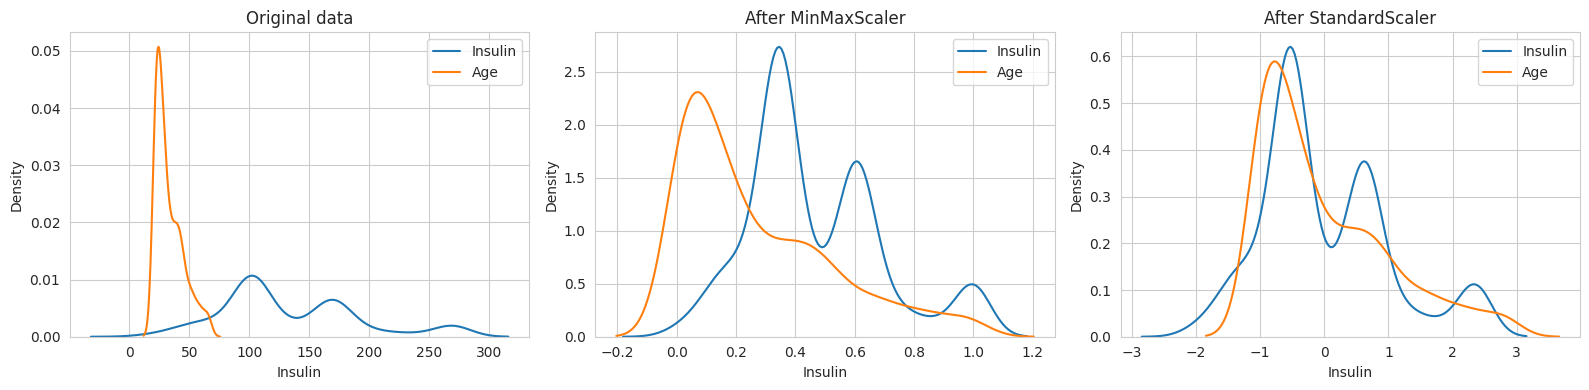

In [15]:
# Visual comparison of the effect of both techniques on two variables with very different scales
sample_columns = ['Insulin', 'Age']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for col in sample_columns:
    sns.kdeplot(X[col], ax=axes[0], label=col)
axes[0].set_title('Original data')
axes[0].legend()

for col in sample_columns:
    sns.kdeplot(X_minmax[col], ax=axes[1], label=col)
axes[1].set_title('After MinMaxScaler')
axes[1].legend()

for col in sample_columns:
    sns.kdeplot(X_standard[col], ax=axes[2], label=col)
axes[2].set_title('After StandardScaler')
axes[2].legend()

plt.tight_layout()
plt.show()


### Comparing the effects

- **MinMaxScaler** compresses all variables into the [0, 1] range, preserving the shape of the original
  distribution, but it is sensitive to remaining outliers (a single extreme value distorts the whole scale).
- **StandardScaler** centers the data at mean 0 with standard deviation 1, making it more robust when variables
  have very different units and magnitudes (e.g. `Insulin`, which ranges from 0 to hundreds, vs.
  `DiabetesPedigreeFunction`, which ranges from 0 to a few units). It usually works better with distance-based
  or gradient-based algorithms (KNN, SVM, logistic regression, neural networks).
- For tree-based models (Random Forest, Gradient Boosting), scaling is generally not required, but it does not
  hurt the results either.

Both scaled datasets (`X_minmax` and `X_standard`) are now ready to be used to train a classification model,
together with the target `y` (`Outcome`).
